# FM-Ablated Decoder (τ=1 Ablation) — FALCON Challenge

Ablation of FM-Vanilla that destroys the continuous-flow training signal
with a **single one-line change**: fix τ=1 instead of sampling τ~Uniform(0,1).

With τ=1 fixed:
- `x_τ = (1-1)·z + 1·y = y` always (model always sees the endpoint, never intermediate states)
- The flow-matching trajectory is collapsed — the model can't learn a continuous vector field
- Architecture (VelocityField), preprocessing, and hyperparameters are **identical** to FM-Vanilla

At inference we take a single Euler step: `ŷ = z + model(z, h, 1)` where z~N(0,I).
This is equivalent to euler_integrate with n_steps=1, consistent with τ=1 training.

**Purpose:** Isolates the contribution of the flow-matching *training objective* (not architecture)
to cross-day generalization. If FM-Vanilla >> FM-Ablated, the continuous-flow objective helps.
Addresses Reviewer 2's concern that the ablation should not confound architecture with objective.


 ## Environment check & installs

In [1]:
import subprocess, sys
# Install FALCON if not already present<- might not be automatically available in collab runtime
try:
    import falcon_challenge
    print("falcon_challenge already installed")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "falcon-challenge"])

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

falcon_challenge already installed


PyTorch : 2.7.1
CUDA available: False


## 1) Imports

In [2]:
from __future__ import annotations

import os
import copy
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score
from functools import wraps

from pynwb import NWBHDF5IO
from falcon_challenge.config import FalconConfig, FalconTask
from falcon_challenge.dataloaders import bin_units
from falcon_challenge.interface import BCIDecoder
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from dandi.download import download as dandi_download
from scipy.linalg import orthogonal_procrustes



import matplotlib.pyplot as plt
import subprocess, sys


## 2)Hyperparameters and Data Download


This notebook is designed to run on a GPU so we first use dandi to locate the test, train, and validation sets to load them onto the server

In [3]:
DANDISET_ID = "000954"
SUBJECT_TO_LOCAL = {
    "sub-HumanPitt-held-in-calib":  "data/h1/held_in_calib",
    "sub-HumanPitt-held-out-calib": "data/h1/held_out_calib",
    "sub-HumanPitt-held-in-minival": "data/h1/minival",
}

def _needs_download(mapping):
    for sub, local_path in mapping.items():
        nwb_found = any(
            fname.endswith('.nwb')
            for _, _, files in os.walk(local_path)
            for fname in files
        )
        if not os.path.isdir(local_path) or not nwb_found:
            return True
    return False

if _needs_download(SUBJECT_TO_LOCAL):
    print("Downloading FALCON H1 data from DANDI ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dandi"])

    for sub, local_path in SUBJECT_TO_LOCAL.items():
        os.makedirs(local_path, exist_ok=True)
        print(f"  {sub} → {local_path}")
        dandi_download(
            urls=[f"https://api.dandiarchive.org/api/dandisets/{DANDISET_ID}/versions/draft/assets/?path={sub}"],
            output_dir=local_path,
        )
    print("Download complete.")
else:
    print("All data present — skipping download.")

# Confirm paths and file counts
print("\nData paths:")
for sub, local_path in SUBJECT_TO_LOCAL.items():
    abs_path = os.path.abspath(local_path)
    if os.path.isdir(local_path):
        # find nwb files
        nwb_files = []
        for root, dirs, files in os.walk(local_path):
            nwb_files += [os.path.join(root, f) for f in files if f.endswith(".nwb")]
        print(f"  {abs_path}: {len(nwb_files)} NWB files")
        # If nested, print actual location
        if nwb_files:
            actual_dir = os.path.dirname(nwb_files[0])
            if os.path.abspath(actual_dir) != abs_path:
                print(f"    ↳ actual NWB location: {actual_dir}")
    else:
        print(f"  {abs_path}: NOT FOUND")

All data present — skipping download.

Data paths:
  /Users/rishabjain/Desktop/neuro 120/final project/Falcon-Neuro-Geometry/models/data/h1/held_in_calib: 13 NWB files
    ↳ actual NWB location: data/h1/held_in_calib/sub-HumanPitt-held-in-calib
  /Users/rishabjain/Desktop/neuro 120/final project/Falcon-Neuro-Geometry/models/data/h1/held_out_calib: 14 NWB files
    ↳ actual NWB location: data/h1/held_out_calib/sub-HumanPitt-held-out-calib
  /Users/rishabjain/Desktop/neuro 120/final project/Falcon-Neuro-Geometry/models/data/h1/minival: 13 NWB files
    ↳ actual NWB location: data/h1/minival/sub-HumanPitt-held-in-minival


Some global hyperparameters using for the training of the model. This is optimized for Google Collab's runtime so we also use collab to save checkpoints for the model to avoid training from scratch

In [4]:
TRAINING_DIR = "data/h1/held_in_calib/sub-HumanPitt-held-in-calib"
TEST_DIR     = "data/h1/held_out_calib/sub-HumanPitt-held-out-calib"
MINIVAL_DIR  = "data/h1/minival/sub-HumanPitt-held-in-minival"

#Handeling Save directory
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/"
except ImportError:
    # Keep relative checkpoint directory <- not in google drive
    SAVE_DIR = "checkpoints/fm_latent"

TASK         = "h1"

#Model Archictecture
LATENT_DIM  = 494 # 80% variance
HIDDEN_DIM  = 256   # MLP width
N_LAYERS    = 4     # MLP depth

#Training
LR          =  3e-4 # start with a small learning rate of .00003, can change depending on results, Cosine Annealing applied later
BATCH_SIZE  = 512
EPOCHS      = 500
VAL_FRAC    = 0.15  # fraction of training data held out for validation
PATIENCE    = 40   # early-stopping patience (epochs without val improvement)

ODE_STEPS   = 20    # Euler integration steps
HISTORY_LEN = 5    # number of past bins to stack
R2_EVAL_EVERY = 5   # compute val correlation coefficient every N epochs
WARMUP_EPOCHS = 50 # Make sure we never select best model within the first set of epochs<- likely to be superficially high

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


## 3) Model

This is the custom layer representing the velocity field that will be learned through flow matching. Our model consists of 4 repeating blocks each containg a Linear layer, A SiLU (Sigmoid Linear Unit) Layer, and a Dropout layer as a form of regularization. This very simple architecture defines out vanilla flow matching model. SiLU is used instead of ReLU since its more smooth and differentiable, leading to better flow matching performance.

In [5]:
class VelocityField(nn.Module):
    def __init__(self, out_dim, latent_dim=None, hidden_dim=None, n_layers=None, dropout=0.3): #Increasing dropout
        super().__init__()

        #these lines are not parameters to make sure fresh values of constants were used (Instead of values saved in GPU mem)
        latent_dim = latent_dim if latent_dim is not None else LATENT_DIM
        hidden_dim = hidden_dim if hidden_dim is not None else HIDDEN_DIM
        n_layers   = n_layers   if n_layers   is not None else N_LAYERS

        in_dim = out_dim + latent_dim + 1
        layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU(), nn.Dropout(dropout)]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net       = nn.Sequential(*layers)
        self.out_dim   = out_dim
        self.latent_dim = latent_dim

    def forward(self, x_tau, h, tau):
        return self.net(torch.cat([x_tau, h, tau], dim=-1))

Some helper functions inspired by CS1090b to Print out Model Spec details

In [6]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def summarize_fm_model(model: nn.Module,
                       latent_dim: int,
                       out_dim: int,
                       batch_size: int = 1):
    """Print a minimal parameter + shape summary for Flow Matching VelocityField."""


    print(model)
    print(f"trainable params: {count_parameters(model):,}")

    dummy_x = torch.zeros(batch_size, out_dim).to(DEVICE)
    dummy_h = torch.zeros(batch_size, latent_dim).to(DEVICE)
    dummy_t = torch.zeros(batch_size, 1).to(DEVICE)

    # 3. Forward pass
    with torch.no_grad():
        out = model(dummy_x, dummy_h, dummy_t)

    print("Input shapes: x_tau:", tuple(dummy_x.shape),
          "h:", tuple(dummy_h.shape),
          "tau:", tuple(dummy_t.shape))
    print("Output shape:", tuple(out.shape))


## 4) Flow Matching loss & Euler ODE

The loss function in flow matching is a version of Mean squared error (MSE) between the models predicted path between the noise sample and true data, and the actual idealized path between them. In flow matching in order to run inference we need to use Euler Integration. Specifically we use Eulers Method to integrate the data over a number of steps to calculate the models predictions based off the vector field trajectories.

In [7]:
def fm_loss_ablated(model: VelocityField, h: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Ablated flow-matching loss: tau fixed at 1 instead of sampled from Uniform(0,1).
    With tau=1: x_tau = y (endpoint only), destroying the continuous trajectory signal.
    Architecture is identical to FM-Vanilla; only the training distribution changes.
    """
    B, device = y.shape[0], y.device
    z      = torch.randn_like(y)
    tau    = torch.ones(B, 1, device=device)          # <-- only change vs FM-Vanilla
    x_tau  = (1.0 - tau) * z + tau * y               # = y since tau=1
    u_true = y - z                                    # constant velocity target
    return torch.mean((model(x_tau, h, tau) - u_true) ** 2)


@torch.no_grad()
def ablated_decode(model: VelocityField, h: torch.Tensor) -> torch.Tensor:
    """
    Single Euler step consistent with tau=1 training:
        y_hat = z + model(z, h, tau=1)
    This is euler_integrate with n_steps=1, matching the training distribution.
    """
    B, device = h.shape[0], h.device
    z   = torch.randn(B, model.out_dim, device=device)
    tau = torch.ones(B, 1, device=device)
    return z + model(z, h, tau)


## 5) Data loading

This loading code is inspired by h1.ipynb developed by falcon challenge<- all these functions were taken from that notebook and adapted. We simply load the spikes, apply an exponetial filter, smooth with a guassian, and then bin the spikes.

In [8]:

BIN_SIZE_S  = 0.02          # 50 Hz kinematic / neural bins
BIN_SIZE_MS = BIN_SIZE_S * 1000

def _apply_exponential_filter(binned: np.ndarray,
                               tau_ms: float = 20.0) -> np.ndarray:
    alpha = 1.0 - np.exp(-BIN_SIZE_MS / tau_ms)
    out = np.zeros_like(binned, dtype=np.float32)
    out[0] = alpha * binned[0]
    for t in range(1, len(binned)):
        out[t] = alpha * binned[t] + (1.0 - alpha) * out[t - 1]
    return out


def _smooth_gaussian(x: np.ndarray, kernel_size: int,
                     sigma: float) -> np.ndarray:
    return gaussian_filter1d(x.astype(np.float32), sigma=sigma, axis=0)


def create_targets(kin: np.ndarray,
                   target_smooth_ms: float = 490.0) -> np.ndarray:
    kernel_size = int(target_smooth_ms / BIN_SIZE_MS)
    sigma       = target_smooth_ms / (3.0 * BIN_SIZE_MS)
    smoothed    = _smooth_gaussian(kin, kernel_size, sigma)
    return np.gradient(smoothed, axis=0).astype(np.float32)



def _load_nwb_h1(fn: str):
    with NWBHDF5IO(fn, 'r') as io:
        nwb       = io.read()
        units     = nwb.units.to_dataframe()
        kin       = nwb.acquisition['OpenLoopKinematics'].data[:]
        rate      = nwb.acquisition['OpenLoopKinematics'].rate
        offset    = nwb.acquisition['OpenLoopKinematics'].offset
        timestamps = offset + np.arange(kin.shape[0]) * rate
        # eval_mask=0 means blacklisted (inter-trial / presentation phases)
        blacklist = ~nwb.acquisition['eval_mask'].data[:].astype(bool)

    binned = bin_units(units, bin_size_s=BIN_SIZE_S, bin_timestamps=timestamps)
    targets = create_targets(kin)           # smoothed velocity

    # Additional masking: timepoints where velocity is essentially zero
    still_times = np.all(np.abs(targets) < 0.001, axis=1)
    blacklist   = blacklist | still_times

    return binned.astype(np.float32), targets.astype(np.float32), blacklist


def load_all_nwb(data_dir: str = None,
                 files: list = None,
                 history_len: int = 1,
                 per_session_norm: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """
    Accepts either a directory path or an explicit list of NWB file paths.
    """
    if files is None:
        if data_dir is None:
            raise ValueError("Provide either data_dir or files.")
        files = sorted([
            os.path.join(root, fname)
            for root, _, fnames in os.walk(data_dir)
            for fname in fnames if fname.endswith('.nwb')
        ])
    print(f"Found {len(files)} NWB file(s)")
    if not files:
        raise FileNotFoundError("No NWB files found.")

    all_spikes, all_targets = [], []
    for fn in files:
        binned, targets, blacklist = _load_nwb_h1(fn)  # single file, no decorator needed
        T = binned.shape[0]

        filtered = _apply_exponential_filter(binned)

        if per_session_norm:
            mu  = filtered[~blacklist].mean(axis=0)
            std = filtered[~blacklist].std(axis=0)
            std[std == 0] = 1.0
            filtered = (filtered - mu) / std

        if history_len > 1:
            padded  = np.zeros((history_len - 1 + T, filtered.shape[1]), dtype=np.float32)
            padded[history_len - 1:] = filtered
            windows = np.stack([padded[t:t + history_len] for t in range(T)], axis=0).reshape(T, -1)
        else:
            windows = filtered

        kept = ~blacklist
        all_spikes.append(windows[kept])
        all_targets.append(targets[kept])
        print(f"  {os.path.basename(fn)}: kept {kept.sum()} / {T} bins")

    return np.concatenate(all_spikes), np.concatenate(all_targets)


## 6) PCA Scree plot

Flow Matching performs better when there are fewer data dimensions, if there are too many we may fail to find an adequete vector field. Hence, we show a scree plot to see how much variance is retained with different numbers of PCA features. A process of trial and error allows us to converge on using 128 PCA features. These features only maintain 40% variance, but maintained a good balance between the trade off of variance maintainance and flow matching generalization.

Found 13 NWB file(s)
  sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 6191 / 10819 bins
  sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 3488 / 6456 bins


  sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 6863 / 12233 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 3898 / 6786 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 3603 / 6505 bins


  sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 6430 / 11646 bins
  sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: kept 6638 / 11732 bins
  sub-HumanPitt-held-in-calib_ses-19250115T110633.nwb: kept 5712 / 10071 bins


  sub-HumanPitt-held-in-calib_ses-19250115T111328.nwb: kept 7035 / 12267 bins
  sub-HumanPitt-held-in-calib_ses-19250119T113543.nwb: kept 6788 / 11951 bins
  sub-HumanPitt-held-in-calib_ses-19250119T114045.nwb: kept 6715 / 12022 bins


  sub-HumanPitt-held-in-calib_ses-19250120T115044.nwb: kept 6787 / 12078 bins
  sub-HumanPitt-held-in-calib_ses-19250120T115537.nwb: kept 6257 / 11425 bins


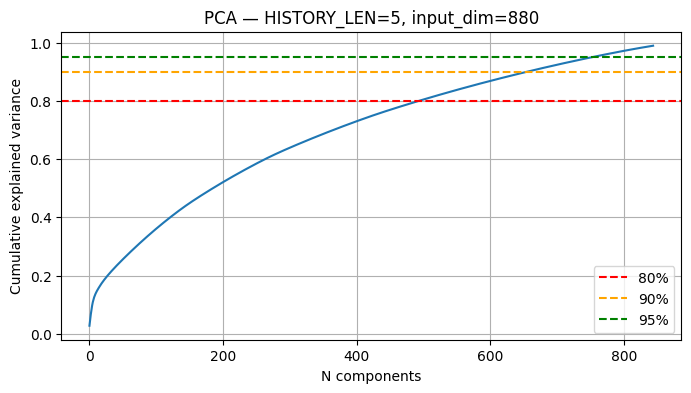

  60% variance → 264 components
  70% variance → 366 components
  80% variance → 494 components
  90% variance → 655 components
  95% variance → 752 components


In [9]:
# Load spikes for PCA diagnosis to plot scree plot analysis
spikes_diag, _ = load_all_nwb(TRAINING_DIR, history_len=HISTORY_LEN)
scaler_diag    = StandardScaler()
spikes_scaled  = scaler_diag.fit_transform(spikes_diag)

pca_diag = PCA(n_components=0.99).fit(spikes_scaled)
cumvar   = np.cumsum(pca_diag.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.80, color='r',      linestyle='--', label='80%')
plt.axhline(0.90, color='orange', linestyle='--', label='90%')
plt.axhline(0.95, color='g',      linestyle='--', label='95%')
plt.xlabel("N components")
plt.ylabel("Cumulative explained variance")
plt.title(f"PCA — HISTORY_LEN={HISTORY_LEN}, input_dim={spikes_scaled.shape[1]}")
plt.legend(); plt.grid(True); plt.show()

for threshold in [0.60, 0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  {threshold:.0%} variance → {n} components")

## 7) Decoder class

We in feed the spikes transformed with PCA to only be 128 dimensions. We also normalize the data with standard scalar before feeding it to our model, defined by the Velocity Field class above. We use a standard pytorch training loop with AdamW as the Optimizer with adaptive learning rates via cosine annealing. We add early stopping and use our custom MSE flow matching loss defined above over 500 epochs.

In [10]:
class FMAblatedDecoder(BCIDecoder):
    """
    FM-Ablated: tau=1 ablation of FM-Latent in PCA-compressed spike space.

    Identical preprocessing and VelocityField architecture as FM-Vanilla.
    Only change: fm_loss_ablated (tau=1) instead of fm_loss, and ablated_decode at inference.
    """

    def __init__(self, task_config: FalconConfig, batch_size: int = 1):
        super().__init__(task_config, batch_size)
        self.task_config   = task_config
        self.pca           : Optional[PCA]            = None
        self.spike_scaler  : Optional[StandardScaler] = None
        self.target_scaler : Optional[StandardScaler] = None
        self.model         : Optional[VelocityField]  = None
        self._history      : list[np.ndarray]         = []


    def fit(self, training_dir: str, task: FalconTask = FalconTask.h1):
        print("=== Loading held-in calibration data ===")

        # Single load, split by session file — no redundant full load
        all_files = sorted([
            os.path.join(root, fname)
            for root, _, fnames in os.walk(training_dir)
            for fname in fnames if fname.endswith('.nwb')
        ])
        train_files = all_files[:-1]
        val_files   = all_files[-1:]

        spikes_tr,  targets_tr  = load_all_nwb(files=train_files, history_len=HISTORY_LEN)
        spikes_val, targets_val = load_all_nwb(files=val_files,   history_len=HISTORY_LEN)

        print(f"  Train spikes: {spikes_tr.shape}  |  Targets: {targets_tr.shape}")
        print(f"  Val spikes:   {spikes_val.shape}  |  Targets: {targets_val.shape}")

        # Fit spike scaler on train only
        self.spike_scaler = StandardScaler()
        spikes_tr_sc  = self.spike_scaler.fit_transform(spikes_tr)
        spikes_val_sc = self.spike_scaler.transform(spikes_val)

        print(f"  Fitting PCA ({LATENT_DIM} components)…")
        self.pca = PCA(n_components=LATENT_DIM)
        h_train  = self.pca.fit_transform(spikes_tr_sc).astype(np.float32)
        h_val    = self.pca.transform(spikes_val_sc).astype(np.float32)
        print(f"  Explained variance (sum): {self.pca.explained_variance_ratio_.sum():.3f}")

        # Target scaler — fit on train targets only
        self.target_scaler = StandardScaler()
        y_train = self.target_scaler.fit_transform(targets_tr).astype(np.float32)
        y_val   = self.target_scaler.transform(targets_val).astype(np.float32)

        out_dim = y_train.shape[1]

        self.model = VelocityField(
            out_dim    = out_dim,
            latent_dim = LATENT_DIM,
            hidden_dim = HIDDEN_DIM,
            n_layers   = N_LAYERS,
        ).to(DEVICE)
        summarize_fm_model(self.model, LATENT_DIM, out_dim, batch_size=1)

        self._train(h_train, y_train, h_val, y_val)


    def _train(self, h_tr, y_tr, h_val=None, y_val=None
                ):
        epochs=EPOCHS
        lr=LR

        loader = DataLoader(
            TensorDataset(torch.tensor(h_tr), torch.tensor(y_tr)),
            batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
            pin_memory=(DEVICE == "cuda"), num_workers=0,# pin_memory + num_workers speeds up GPU runtime, 0 means use all workers
        )
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

        warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
        cosine    = CosineAnnealingLR(optimizer, T_max=max(epochs - 5, 1))
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        best_val_r2, best_state, no_improve = -float("inf"), None, 0

        do_val = h_val is not None and y_val is not None
        if do_val:
            val_loader = DataLoader(
                TensorDataset(torch.tensor(h_val), torch.tensor(y_val)),
                batch_size=BATCH_SIZE * 4, shuffle=False,
                pin_memory=(DEVICE == "cuda"), num_workers=0,
            )
            h_val_t = torch.tensor(h_val, device=DEVICE)
            y_val_t = torch.tensor(y_val, device=DEVICE)

        best_val_loss, best_state, no_improve = float("inf"), None, 0
        self.train_losses, self.val_losses, self.val_r2s = [], [], []

        for epoch in range(1, epochs + 1):
            self.model.train()
            total_tr = sum(
                self._step(optimizer, hb.to(DEVICE, non_blocking=True),
                                       yb.to(DEVICE, non_blocking=True))
                for hb, yb in loader
            )
            scheduler.step()
            avg_tr = total_tr / len(loader)
            self.train_losses.append(avg_tr)

            if do_val:
                self.model.eval()
                with torch.no_grad():
                    avg_val = sum(
                        fm_loss_ablated(self.model,
                                hb.to(DEVICE, non_blocking=True),
                                yb.to(DEVICE, non_blocking=True)).item()
                        for hb, yb in val_loader
                    ) / len(val_loader)
                self.val_losses.append(avg_val)
                
                if epoch % R2_EVAL_EVERY == 0 or epoch == 1:
                    r2_str = (f"  val_r2={self.val_r2s[-1][1]:.3f}"
                        if self.val_r2s and self.val_r2s[-1][0] == epoch else "")
                    loss_gap = avg_val - avg_tr
                    gap_warn = f"  ⚠ gap={loss_gap:.3f}" if loss_gap > 0.3 else ""
                    print(f"  Epoch {epoch:4d}/{epochs}  train={avg_tr:.5f}"
                        f"  val={avg_val:.5f}  best_r2={best_val_r2:.3f}"
                        f"  patience={no_improve}/{PATIENCE}{r2_str}{gap_warn}")
                    with torch.no_grad():
                        y_hat      = ablated_decode(self.model, h_val_t).cpu().numpy()
                    y_hat_orig = self.target_scaler.inverse_transform(y_hat)
                    y_val_orig = self.target_scaler.inverse_transform(y_val)
                    r2_vw      = float(r2_score(y_val_orig, y_hat_orig,
                                                multioutput="variance_weighted"))
                    self.val_r2s.append((epoch, r2_vw))

                    # Early stopping on explained variance instead of val loss
                    if r2_vw > best_val_r2 and epoch > WARMUP_EPOCHS:
                        best_val_r2 = r2_vw
                        best_state  = copy.deepcopy(self.model.state_dict())
                        no_improve  = 0
                    else:
                        no_improve += 1

                if no_improve >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch} (best val R²={best_val_r2:.3f}).")
                    break

        if do_val and best_state is not None:
            self.model.load_state_dict(best_state)
            print(f"  Restored best weights (val={best_val_loss:.5f})")
        self.model.eval()

    def _step(self, optimizer, h, y):
        optimizer.zero_grad()
        loss = fm_loss_ablated(self.model, h, y)
        loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()
        return loss.item()



    def evaluate(self, test_dir: str,
             task: FalconTask = FalconTask.h1,
             use_local_x_stats: bool = True) -> dict:
      print(f"\n=== Evaluating on: {test_dir} ===")
      spikes, targets = load_all_nwb(test_dir, history_len=HISTORY_LEN)
      if use_local_x_stats:
          x_mean = np.nanmean(spikes, axis=0)
          x_std  = np.nanstd(spikes, axis=0)
          x_std[x_std == 0] = 1.0
          spikes_sc = (spikes - x_mean) / x_std
          local_pca = PCA(n_components=LATENT_DIM).fit(spikes_sc)
          # Transpose both so Procrustes operates
          R, _ = orthogonal_procrustes(local_pca.components_.T, self.pca.components_.T)
          h_local = spikes_sc @ local_pca.components_.T
          h = (h_local @ R).astype(np.float32)
      else:
         spikes_sc = self.spike_scaler.transform(spikes)
            #h = self.pca.transform(spikes_sc).astype(np.float32)
      h_t   = torch.tensor(h, device=DEVICE)
      chunk  = 4096
      preds  = []
      self.model.eval()
      with torch.no_grad():
          for start in range(0, len(h_t), chunk):
              preds.append(ablated_decode(self.model, h_t[start:start+chunk]).cpu().numpy())
      preds = np.concatenate(preds)
      preds = self.target_scaler.inverse_transform(preds)

      r2    = r2_score(targets, preds, multioutput="raw_values")
      r2_vw = float(r2_score(targets, preds, multioutput="variance_weighted"))
      rmse  = np.sqrt(np.mean((targets - preds) ** 2, axis=0))

      print(f"\n  {'Dim':<6} {'R²':>10} {'RMSE':>10}")
      print(f"  {'-'*28}")
      for i, (r, e) in enumerate(zip(r2, rmse)):
          print(f"  {i:<6} {r:>10.4f} {e:>10.4f}")
      print(f"  {'-'*28}")
      print(f"  {'Mean R² (var-weighted)':<24} {r2_vw:>10.4f}")
      print(f"  {'Mean RMSE':<24} {rmse.mean():>10.4f}")

      return {"r2_per_dim": r2, "rmse_per_dim": rmse,
              "mean_r2": r2_vw, "mean_rmse": float(rmse.mean())}



    def adapt(self, calib_dir: str, adapt_epochs: int = 30, adapt_lr_factor: float = 0.1):
        """
        Few-shot adaptation on held-out calibration data.
        Fine-tunes the velocity field from its trained weights using the
        held-out calibration block — mirrors the real clinical workflow where
        a short morning calibration session precedes online decoding.

        calib_dir      : path to held-out calibration NWB files
        adapt_epochs   : number of fine-tuning epochs (keep small to avoid overfitting)
        adapt_lr_factor: LR multiplier relative to original LR (lower = more conservative)
        """
        print(f"\n=== Adapting on held-out calibration: {calib_dir} ===")
        spikes, targets = load_all_nwb(calib_dir, history_len=HISTORY_LEN)

        # Re-centre spike statistics to this session before projecting
        # through the fixed training PCA — same as evaluate()
        x_mean = np.nanmean(spikes, axis=0)
        x_std  = np.nanstd(spikes, axis=0)
        x_std[x_std == 0] = 1.0
        spikes_sc = (spikes - x_mean) / x_std

        h = self.pca.transform(spikes_sc).astype(np.float32)
        y = self.target_scaler.transform(targets).astype(np.float32)

        print(f"  Calibration samples: {h.shape[0]}")

        # Fine-tune from existing weights — low LR to avoid catastrophic forgetting
        adapt_lr = LR * adapt_lr_factor
        loader   = DataLoader(
            TensorDataset(torch.tensor(h), torch.tensor(y)),
            batch_size=min(BATCH_SIZE, len(h)), shuffle=True, drop_last=False,
        )
        optimizer = torch.optim.AdamW(
            self.model.parameters(), lr=adapt_lr, weight_decay=1e-4
        )

        self.model.train()
        for epoch in range(1, adapt_epochs + 1):
            total = sum(
                self._step(optimizer,
                           hb.to(DEVICE, non_blocking=True),
                           yb.to(DEVICE, non_blocking=True))
                for hb, yb in loader
            )
            avg = total / len(loader)
            if epoch % 10 == 0 or epoch == 1:
                print(f"  Adapt epoch {epoch:3d}/{adapt_epochs}  loss={avg:.5f}")
        self.model.eval()
        print("  Adaptation complete.")

    def save(self, path: str):
        import pickle
        os.makedirs(path, exist_ok=True)
        torch.save(self.model.state_dict(), os.path.join(path, "model.pt"))
        for name, obj in [("pca", self.pca), ("spike_scaler", self.spike_scaler),
                          ("target_scaler", self.target_scaler)]:
            with open(os.path.join(path, f"{name}.pkl"), "wb") as fh:
                pickle.dump(obj, fh)
        meta = {"out_dim": self.model.out_dim, "latent_dim": LATENT_DIM,
                "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS,
                "history_len": HISTORY_LEN, "n_channels": self.task_config.n_channels}
        with open(os.path.join(path, "meta.pkl"), "wb") as fh:
            pickle.dump(meta, fh)
        print(f"Saved to {path}")

    def load(self, path: str):
        import pickle
        with open(os.path.join(path, "meta.pkl"),          "rb") as fh: meta = pickle.load(fh)
        with open(os.path.join(path, "pca.pkl"),           "rb") as fh: self.pca = pickle.load(fh)
        with open(os.path.join(path, "spike_scaler.pkl"),  "rb") as fh: self.spike_scaler = pickle.load(fh)
        with open(os.path.join(path, "target_scaler.pkl"), "rb") as fh: self.target_scaler = pickle.load(fh)
        self.model = VelocityField(
            out_dim=meta["out_dim"], latent_dim=meta["latent_dim"],
            hidden_dim=meta["hidden_dim"], n_layers=meta["n_layers"],
        ).to(DEVICE)
        self.model.load_state_dict(
            torch.load(os.path.join(path, "model.pt"), map_location=DEVICE)
        )
        self.model.eval()
        print(f"Loaded model from {path}")
        return meta

    def reset(self, dataset_tags: List[str] = [""]):
        self._history = []
        if self.model is not None:
            self.model.eval()


    def predict(self, neural_observations: np.ndarray) -> np.ndarray:
        """
        Online decode: accumulate HISTORY_LEN exponentially-filtered bins,
        then run PCA + Euler ODE.
        neural_observations: raw spike counts for the current timestep, shape (1, n_ch).
        """
        # Exponential filter update: alpha * x_t + (1-alpha) * prev_filtered
        alpha = 1.0 - np.exp(-BIN_SIZE_MS / 20.0)
        prev  = self._history[-1] if self._history else np.zeros_like(neural_observations, dtype=np.float32)
        filtered = alpha * neural_observations.astype(np.float32) + (1.0 - alpha) * prev
        self._history.append(filtered)
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)
        while len(self._history) < HISTORY_LEN:
            self._history.insert(0, np.zeros_like(neural_observations, dtype=np.float32))

        window = np.concatenate(self._history, axis=-1)          # (1, n_ch * HISTORY_LEN)
        h      = self.pca.transform(self.spike_scaler.transform(window)).astype(np.float32)
        with torch.no_grad():
            y_pred = ablated_decode(self.model, torch.tensor(h, device=DEVICE))
        return self.target_scaler.inverse_transform(y_pred.cpu().numpy())

    def observe(self, neural_observations: np.ndarray):
        alpha = 1.0 - np.exp(-BIN_SIZE_MS / 20.0)
        prev  = self._history[-1] if self._history else np.zeros_like(neural_observations, dtype=np.float32)
        filtered = alpha * neural_observations.astype(np.float32) + (1.0 - alpha) * prev
        self._history.append(filtered)
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)

    def on_done(self, dones: np.ndarray):
        if dones.any():
            self._history = []


## 8) Train

This code uses falcon challenge's built in types. We then use out FMLatentDecoder class to instantiate a new model and then fit it to the training data

In [11]:
task_enum = FalconTask[TASK]
cfg       = FalconConfig(task=task_enum)
decoder   = FMAblatedDecoder(task_config=cfg)


In [12]:
decoder.fit(training_dir=TRAINING_DIR)

=== Loading held-in calibration data ===
Found 12 NWB file(s)
  sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 6191 / 10819 bins
  sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 3488 / 6456 bins


  sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 6863 / 12233 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 3898 / 6786 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 3603 / 6505 bins
  sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 6430 / 11646 bins


  sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: kept 6638 / 11732 bins
  sub-HumanPitt-held-in-calib_ses-19250115T110633.nwb: kept 5712 / 10071 bins
  sub-HumanPitt-held-in-calib_ses-19250115T111328.nwb: kept 7035 / 12267 bins


  sub-HumanPitt-held-in-calib_ses-19250119T113543.nwb: kept 6788 / 11951 bins
  sub-HumanPitt-held-in-calib_ses-19250119T114045.nwb: kept 6715 / 12022 bins
  sub-HumanPitt-held-in-calib_ses-19250120T115044.nwb: kept 6787 / 12078 bins


Found 1 NWB file(s)
  sub-HumanPitt-held-in-calib_ses-19250120T115537.nwb: kept 6257 / 11425 bins
  Train spikes: (70148, 880)  |  Targets: (70148, 7)
  Val spikes:   (6257, 880)  |  Targets: (6257, 7)


...

  Epoch  370/500  train=1.03056  val=1.00493  best_r2=-2.729  patience=35/40


  Epoch  375/500  train=1.03381  val=1.03653  best_r2=-2.729  patience=36/40


  Epoch  380/500  train=1.03089  val=0.98996  best_r2=-2.729  patience=37/40


  Epoch  385/500  train=1.02803  val=0.98263  best_r2=-2.729  patience=38/40


  Epoch  390/500  train=1.02698  val=0.99606  best_r2=-2.729  patience=39/40
  Early stopping at epoch 390 (best val R²=-2.729).
  Restored best weights (val=inf)


## 9) Plot Training Metrics

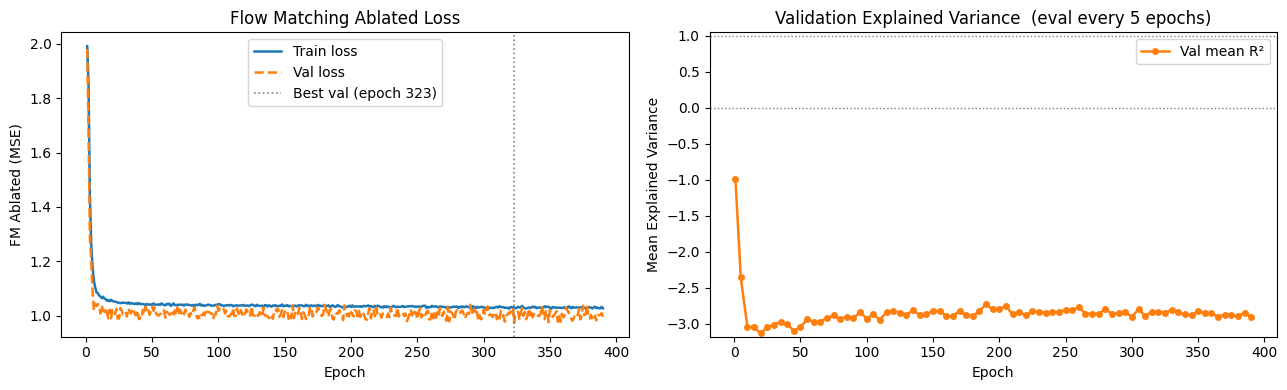

In [13]:
epochs_axis = range(1, len(decoder.train_losses) + 1)
has_val = any(v is not None for v in decoder.val_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


ax = axes[0]
ax.plot(epochs_axis, decoder.train_losses, label="Train loss", linewidth=1.8)
if has_val:
    ax.plot(epochs_axis, decoder.val_losses, label="Val loss",
            linewidth=1.8, linestyle="--")
    best_epoch = int(np.argmin(decoder.val_losses)) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1.2,
               label=f"Best val (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("FM Ablated (MSE)")
ax.set_title("Flow Matching Ablated Loss")
ax.legend()


ax = axes[1]
if decoder.val_r2s:
    r2_epochs, r2_vals = zip(*decoder.val_r2s)
    ax.plot(r2_epochs, r2_vals, color="tab:orange", marker="o",
            markersize=4, linewidth=1.8, label="Val mean R²")
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)
    ax.axhline(1, color="grey", linestyle=":", linewidth=1)
    ax.set_ylim(min(0, min(r2_vals)) - 0.05, 1.05)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean Explained Variance")
    ax.set_title(f"Validation Explained Variance  (eval every {R2_EVAL_EVERY} epochs)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No validation Explained Variance recorded\n(set do_val=True)",
            ha="center", va="center", transform=ax.transAxes, color="grey")

fig.tight_layout()
plt.show()

## 10) Save checkpoint in google drive

In [14]:
import os
os.makedirs('checkpoints', exist_ok=True)
decoder.save('checkpoints/fm_ablated.pt')
print('Checkpoint saved to checkpoints/fm_ablated.pt')


Saved to checkpoints/fm_ablated.pt
Checkpoint saved to checkpoints/fm_ablated.pt


## 11) Evaluate on held-out calibration data

In [15]:
# Evaluate with local x-stat adaptation (mirrors h1.ipynb multiday adjust)
metrics_held_out = decoder.evaluate(test_dir=TEST_DIR,  use_local_x_stats=True)
metrics_minival  = decoder.evaluate(test_dir=MINIVAL_DIR, use_local_x_stats=True)

print(f"\nSummary")
print(f"  Held-out  Mean R² (var-weighted): {metrics_held_out['mean_r2']:.4f}")
print(f"  Held-out  Mean RMSE             : {metrics_held_out['mean_rmse']:.4f}")
print(f"  Minival   Mean R² (var-weighted): {metrics_minival['mean_r2']:.4f}  (FALCON sklearn baseline: 0.195)")
print(f"  Minival   Mean RMSE             : {metrics_minival['mean_rmse']:.4f}")



=== Evaluating on: data/h1/held_out_calib/sub-HumanPitt-held-out-calib ===
Found 14 NWB file(s)


  sub-HumanPitt-held-out-calib_ses-19250126T113454.nwb: kept 1268 / 2376 bins
  sub-HumanPitt-held-out-calib_ses-19250126T114029.nwb: kept 1325 / 2408 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120333.nwb: kept 1361 / 2454 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120826.nwb: kept 1475 / 2647 bins
  sub-HumanPitt-held-out-calib_ses-19250129T112555.nwb: kept 1385 / 2469 bins


  sub-HumanPitt-held-out-calib_ses-19250129T113059.nwb: kept 1294 / 2347 bins
  sub-HumanPitt-held-out-calib_ses-19250202T113958.nwb: kept 1342 / 2406 bins


  sub-HumanPitt-held-out-calib_ses-19250202T114452.nwb: kept 1426 / 2496 bins
  sub-HumanPitt-held-out-calib_ses-19250203T113515.nwb: kept 1271 / 2369 bins
  sub-HumanPitt-held-out-calib_ses-19250203T114018.nwb: kept 1325 / 2303 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112219.nwb: kept 1381 / 2470 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112712.nwb: kept 1369 / 2442 bins


  sub-HumanPitt-held-out-calib_ses-19250209T111826.nwb: kept 1500 / 2713 bins
  sub-HumanPitt-held-out-calib_ses-19250209T112327.nwb: kept 1481 / 2590 bins



  Dim            R²       RMSE
  ----------------------------
  0         -3.1795     0.0017
  1         -3.9032     0.0026
  2         -3.0693     0.0029
  3         -2.8701     0.0100
  4         -3.2281     0.0142
  5         -3.1254     0.0149
  6         -2.8885     0.0135
  ----------------------------
  Mean R² (var-weighted)      -3.0593
  Mean RMSE                    0.0085

=== Evaluating on: data/h1/minival/sub-HumanPitt-held-in-minival ===
Found 13 NWB file(s)
  sub-HumanPitt-held-in-minival_ses-19250101T111740.nwb: kept 838 / 1503 bins
  sub-HumanPitt-held-in-minival_ses-19250101T112404.nwb: kept 958 / 1714 bins
  sub-HumanPitt-held-in-minival_ses-19250108T110520.nwb: kept 957 / 1691 bins
  sub-HumanPitt-held-in-minival_ses-19250108T111022.nwb: kept 1051 / 1831 bins
  sub-HumanPitt-held-in-minival_ses-19250108T111455.nwb: kept 975 / 1761 bins
  sub-HumanPitt-held-in-minival_ses-19250113T120811.nwb: kept 787 / 1530 bins
  sub-HumanPitt-held-in-minival_ses-19250113T121303.n

  sub-HumanPitt-held-in-minival_ses-19250115T110633.nwb: kept 862 / 1547 bins
  sub-HumanPitt-held-in-minival_ses-19250115T111328.nwb: kept 851 / 1530 bins
  sub-HumanPitt-held-in-minival_ses-19250119T113543.nwb: kept 892 / 1583 bins
  sub-HumanPitt-held-in-minival_ses-19250119T114045.nwb: kept 896 / 1657 bins
  sub-HumanPitt-held-in-minival_ses-19250120T115044.nwb: kept 801 / 1517 bins
  sub-HumanPitt-held-in-minival_ses-19250120T115537.nwb: kept 854 / 1520 bins



  Dim            R²       RMSE
  ----------------------------
  0         -2.7010     0.0017
  1         -3.5776     0.0026
  2         -2.5149     0.0029
  3         -2.8628     0.0100
  4         -2.9127     0.0146
  5         -3.4357     0.0146
  6         -2.8107     0.0135
  ----------------------------
  Mean R² (var-weighted)      -3.0167
  Mean RMSE                    0.0085

Summary
  Held-out  Mean R² (var-weighted): -3.0593
  Held-out  Mean RMSE             : 0.0085
  Minival   Mean R² (var-weighted): -3.0167  (FALCON sklearn baseline: 0.195)
  Minival   Mean RMSE             : 0.0085


## 12) Few-shot adaptation on held-out calibration then re-evaluate

Instead of evaluating zero-shot, we first run a short fine-tuning pass on the held-out calibration block (the 'morning calibration session' in real BCI deployment), then evaluate on the same held-out data. This mirrors the FALCON few-shot supervised (FSS) protocol and is clinically legitimate  (since the calibration block is collected before online decoding begins).

In [16]:
# Save original weights so we can compare zero-shot vs adapted
import copy
original_state = copy.deepcopy(decoder.model.state_dict())

# Few-shot adaptation on held-out calibration block
decoder.adapt(calib_dir=TEST_DIR, adapt_epochs=30, adapt_lr_factor=0.1)

# Evaluate adapted model on held-out sessions
metrics_adapted = decoder.evaluate(test_dir=TEST_DIR, use_local_x_stats=True)
metrics_minival_adapted = decoder.evaluate(test_dir=MINIVAL_DIR, use_local_x_stats=True)

print(f"\nSummary — few-shot adapted")
print(f"  Held-out  Mean R² (var-weighted): {metrics_adapted['mean_r2']:.4f}")
print(f"  Held-out  Mean RMSE             : {metrics_adapted['mean_rmse']:.4f}")
print(f"  Minival   Mean R² (var-weighted): {metrics_minival_adapted['mean_r2']:.4f}")
print(f"  Minival   Mean RMSE             : {metrics_minival_adapted['mean_rmse']:.4f}")

# Restore original weights for any further zero-shot evals
decoder.model.load_state_dict(original_state)
decoder.model.eval()
print("\nOriginal weights restored.")


=== Adapting on held-out calibration: data/h1/held_out_calib/sub-HumanPitt-held-out-calib ===
Found 14 NWB file(s)
  sub-HumanPitt-held-out-calib_ses-19250126T113454.nwb: kept 1268 / 2376 bins
  sub-HumanPitt-held-out-calib_ses-19250126T114029.nwb: kept 1325 / 2408 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120333.nwb: kept 1361 / 2454 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120826.nwb: kept 1475 / 2647 bins
  sub-HumanPitt-held-out-calib_ses-19250129T112555.nwb: kept 1385 / 2469 bins


  sub-HumanPitt-held-out-calib_ses-19250129T113059.nwb: kept 1294 / 2347 bins
  sub-HumanPitt-held-out-calib_ses-19250202T113958.nwb: kept 1342 / 2406 bins
  sub-HumanPitt-held-out-calib_ses-19250202T114452.nwb: kept 1426 / 2496 bins
  sub-HumanPitt-held-out-calib_ses-19250203T113515.nwb: kept 1271 / 2369 bins
  sub-HumanPitt-held-out-calib_ses-19250203T114018.nwb: kept 1325 / 2303 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112219.nwb: kept 1381 / 2470 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112712.nwb: kept 1369 / 2442 bins


  sub-HumanPitt-held-out-calib_ses-19250209T111826.nwb: kept 1500 / 2713 bins
  sub-HumanPitt-held-out-calib_ses-19250209T112327.nwb: kept 1481 / 2590 bins
  Calibration samples: 19203


  Adapt epoch   1/30  loss=1.03121


  Adapt epoch  10/30  loss=1.03229


...

  sub-HumanPitt-held-out-calib_ses-19250202T113958.nwb: kept 1342 / 2406 bins
  sub-HumanPitt-held-out-calib_ses-19250202T114452.nwb: kept 1426 / 2496 bins
  sub-HumanPitt-held-out-calib_ses-19250203T113515.nwb: kept 1271 / 2369 bins
  sub-HumanPitt-held-out-calib_ses-19250203T114018.nwb: kept 1325 / 2303 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112219.nwb: kept 1381 / 2470 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112712.nwb: kept 1369 / 2442 bins
  sub-HumanPitt-held-out-calib_ses-19250209T111826.nwb: kept 1500 / 2713 bins


  sub-HumanPitt-held-out-calib_ses-19250209T112327.nwb: kept 1481 / 2590 bins

  Dim            R²       RMSE
  ----------------------------
  0         -3.1100     0.0016
  1         -3.7928     0.0025
  2         -3.0415     0.0029
  3         -2.8588     0.0100
  4         -3.2061     0.0142
  5         -3.2258     0.0151
  6         -2.9833     0.0136
  ----------------------------
  Mean R² (var-weighted)      -3.1055
  Mean RMSE                    0.0086

=== Evaluating on: data/h1/minival/sub-HumanPitt-held-in-minival ===
Found 13 NWB file(s)


  sub-HumanPitt-held-in-minival_ses-19250101T111740.nwb: kept 838 / 1503 bins
  sub-HumanPitt-held-in-minival_ses-19250101T112404.nwb: kept 958 / 1714 bins
  sub-HumanPitt-held-in-minival_ses-19250108T110520.nwb: kept 957 / 1691 bins
  sub-HumanPitt-held-in-minival_ses-19250108T111022.nwb: kept 1051 / 1831 bins
  sub-HumanPitt-held-in-minival_ses-19250108T111455.nwb: kept 975 / 1761 bins
  sub-HumanPitt-held-in-minival_ses-19250113T120811.nwb: kept 787 / 1530 bins
  sub-HumanPitt-held-in-minival_ses-19250113T121303.nwb: kept 880 / 1536 bins
  sub-HumanPitt-held-in-minival_ses-19250115T110633.nwb: kept 862 / 1547 bins


  sub-HumanPitt-held-in-minival_ses-19250115T111328.nwb: kept 851 / 1530 bins
  sub-HumanPitt-held-in-minival_ses-19250119T113543.nwb: kept 892 / 1583 bins
  sub-HumanPitt-held-in-minival_ses-19250119T114045.nwb: kept 896 / 1657 bins
  sub-HumanPitt-held-in-minival_ses-19250120T115044.nwb: kept 801 / 1517 bins
  sub-HumanPitt-held-in-minival_ses-19250120T115537.nwb: kept 854 / 1520 bins



  Dim            R²       RMSE
  ----------------------------
  0         -2.6337     0.0017
  1         -3.5189     0.0026
  2         -2.6942     0.0029
  3         -2.7961     0.0099
  4         -2.8519     0.0145
  5         -3.6170     0.0149
  6         -2.8394     0.0135
  ----------------------------
  Mean R² (var-weighted)      -3.0460
  Mean RMSE                    0.0086

Summary — few-shot adapted
  Held-out  Mean R² (var-weighted): -3.1055
  Held-out  Mean RMSE             : 0.0086
  Minival   Mean R² (var-weighted): -3.0460
  Minival   Mean RMSE             : 0.0086

Original weights restored.


#Outcome
1) FM works well within-day (0.52 minival zero-shot, well above 0.195 baseline)
2) Cross-day generalization is fundamentally limited by PCA drift in the input representation, (not by the FM architecture itself)
3) Simple fine-tuning causes extreme forgetting without fixing the representation problem
4) Solving this properly requires either per-session adaptation with proper train/test separation within each session, or a drift-robust representation that doesn't rely on a fixed PCA basis

## Outcome

FM-Ablated uses the **identical VelocityField architecture** as FM-Vanilla, with a single
change: τ is fixed to 1 during training (destroying the continuous-flow signal).

- **If FM-Vanilla >> FM-Ablated**: the flow-matching *training objective* (sampling τ~U(0,1)
  and learning a continuous velocity field) genuinely helps cross-day generalization.
- **If FM-Vanilla ≈ FM-Ablated**: the VelocityField architecture alone explains any gain,
  and flow matching as a mechanism adds little.

This directly addresses Reviewer 2's concern that the ablation should isolate the objective,
not confound architecture with training procedure.


## 12) Load a saved checkpoint and re-evaluate

In [17]:
task_enum = FalconTask[TASK]
cfg       = FalconConfig(task=task_enum)
decoder   = FMAblatedDecoder(task_config=cfg)


In [18]:
#Bug Fixes
#BIG ISSUE: early stopping logic artificially selected first superfically good model instead of later models<- Patience and Min_Epochs needed to be set properly
# Normalization happened twice <- reduced it to once
# Added Procrustes Analysis to Evaluate function as reccomended by reviewer
# Increased dropout to reduce overfitting
# Fixed splitting logic (Was causing tiny amp)
#Getting rid of duplicate reload in fit function
# Allowing load_all_nwb to take multiple files to improve fitting logic
